# MAPPO Evaluation & Rendering

This runs the trained MAPPO policy with the patrolling zoo.

In [1]:
%reload_ext autoreload
%autoreload 2
from onpolicy.scripts.render.render_pettingzoo import main
import os
import yaml
os.environ["WANDB__SERVICE_WAIT"] = "300"

## Configuration

In [2]:
# Set the run directory.
# model_dir = "/data/group/mas/qmas/results/toy_problem_v1/mappo/toy-problem-ensemble3/wandb/run-20250828_140541-nznhbsh7/files"

model_dir = "/data/group/mas/qmas/results/isru_v0/mappo/isru-comms-e200-20x20-worldReset/wandb/run-20251013_114547-6cwer2uq/files"

In [3]:
# Load arguments from the config file.
config_file = os.path.join(model_dir, "config.yaml")
args = yaml.load(open(config_file), Loader=yaml.FullLoader)

def wrap_arg_val(val):
    return {"value": val}

# Set required render-specific arguments. Do not change these!
args["use_wandb"] = wrap_arg_val(False)
args["use_render"] = wrap_arg_val(True)
args["model_dir"] = wrap_arg_val(model_dir)
args["cuda"] = wrap_arg_val(True)
args["cuda_idx"] = wrap_arg_val(0)
args["cuda_idx_predictor"] = wrap_arg_val(0)

In [4]:
# Feel free to change these arguments or add additional arguments here.
args["render_episodes"] = wrap_arg_val(1)
args["episode_length"] = wrap_arg_val(300)
args["max_cycles"] = args["episode_length"]
# args["seed"] = wrap_arg_val(1492)

# args["algorithm_class"] = wrap_arg_val("qmas.variant_three_modules.algorithm.QmasAlgorithm")
# args["policy_class"] = wrap_arg_val("qmas.variant_three_modules.policy.QmasPolicy")

# args["observation_mask"] = wrap_arg_val(False)
# args["observation_radius"] = wrap_arg_val(2)
# args["observation_probability"] = wrap_arg_val(0.1)
args["noisy_memory"] = wrap_arg_val(False)

args["diffusion_autoregression_steps"] = wrap_arg_val(0)
# args["prediction_history_window"] 

# args["prediction_disable"] = wrap_arg_val(True)

In [5]:
# Convert arguments to the appropriate format.
def add_arg(arglist, key, value):
    if value == None:
        return
    if type(value) == bool:
        if value:
            arglist.append(f"--{key}")
        else:
            arglist.append(f"--no-{key}")
    elif type(value) == list:
        arglist.append(f"--{key}")
        arglist.extend([str(v) for v in value])
    else:
        arglist.append(f"--{key}")
        arglist.append(str(value))
arglist = []
for key, value in args.items():
    if type(value) == dict and "value" in value and not key.startswith("_"):
        add_arg(arglist, key, value["value"])
    else:
        add_arg(arglist, key, value)

## Perform Rendering

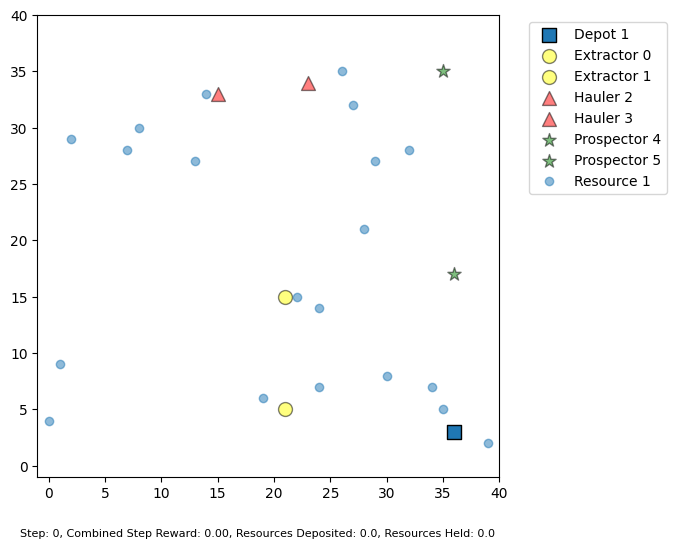

Step 0 - FPS: 74.46 (excluding render) - Reward Total: 65304.20


In [6]:
main(arglist)